# Variable sine wave oscillator

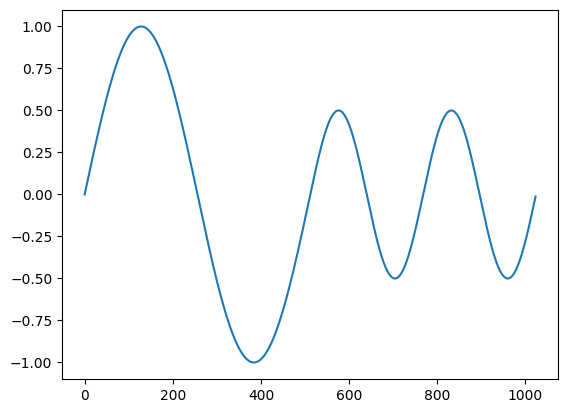

In [1]:
import matplotlib.pyplot as plt
from src.engine.oscillators import SineOscillator, SquareOscillator, SawtoothOscillator, TriangleOscillator

# Create a sine wave oscillator
osc = SineOscillator(freq=1, amp=1, phase=0, sample_rate=512)

# Get 512 samples from the oscillator
samples1 = osc.get_samples(n=512)
osc.freq = 2
osc.amp = 0.5
samples2 = osc.get_samples(n=512)
samples = samples1 + samples2
plt.plot(samples)
plt.show()


## Variable square wave oscillator

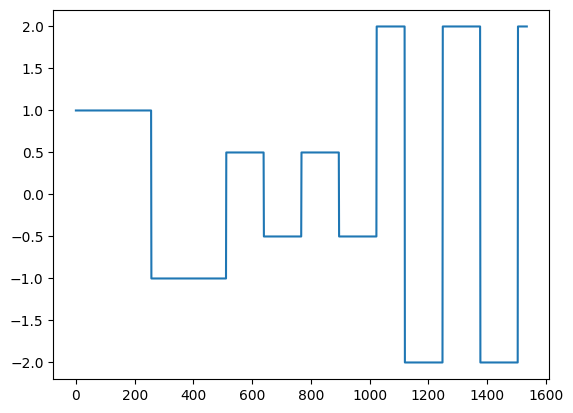

In [2]:
osc = SquareOscillator(freq=1, amp=1, phase=0, sample_rate=512)

# Get 512 samples from the oscillator
samples1 = osc.get_samples(n=512)
osc.freq = 2
osc.amp = 0.5
samples2 = osc.get_samples(n=512)
osc.amp = 2
osc.phase = 45
samples3 = osc.get_samples(n=512)
samples = samples1 + samples2 + samples3
plt.plot(samples)
plt.show()

## Square

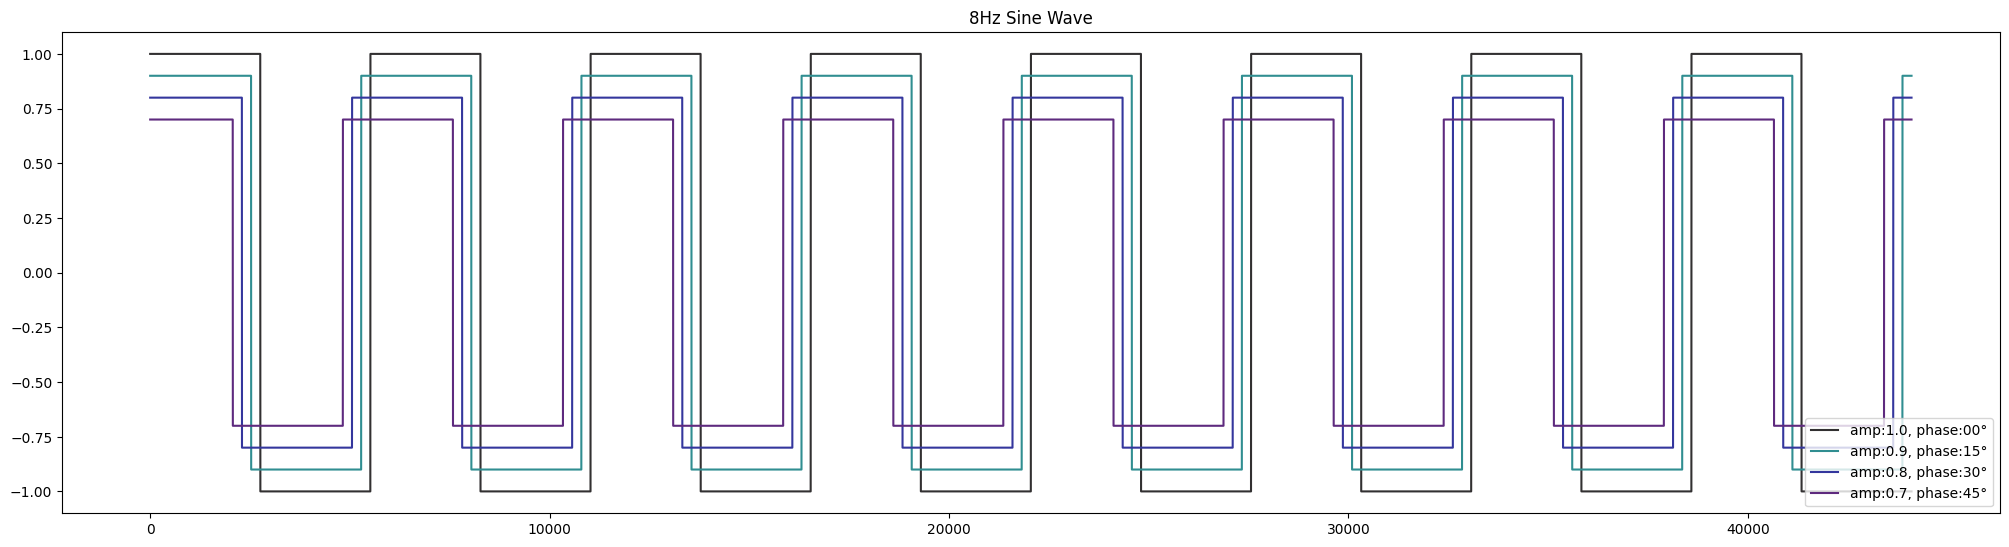

In [3]:
import matplotlib.pyplot as plt
from src.engine.oscillators import SquareOscillator

figsize=(25, 6.25)
colors = "#323031", "#308E91", "#34369D","#5E2A7E", "#5E2A7E", "#6F3384"


def plot_osc(Osc, name=""):
    fig = plt.figure(figsize=figsize)

    f = 8
    plt.title(f"{f}Hz {name} Wave")
    for a,p,c in zip([1.0,0.9,0.8,0.7],[0,15,30,45],colors):
        osc = Osc(freq=f,amp=a,phase=p)

        plt.plot(osc.get_samples(), color=c, label=f"amp:{a}, phase:{p:02}°")

    plt.legend(loc='lower right')
    fig.savefig(f"{name.lower()}_all.jpg")

plot_osc(SquareOscillator, "Sine")


## Triangle

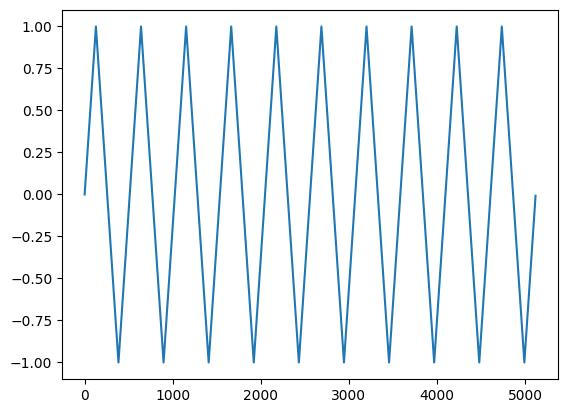

In [4]:
from src.engine.generators_lazy import Triangle

osc = TriangleOscillator(freq=1, amp=1, phase=0, sample_rate=512)
samples = osc.get_samples(n=512*10)

plt.plot(samples)
plt.show()


## Sawtooth

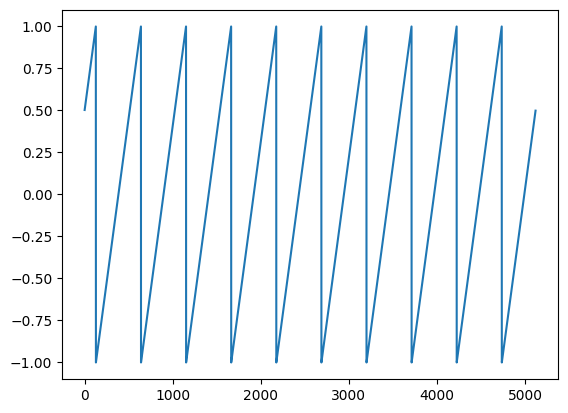

In [5]:
from src.engine.generators_lazy import Saw

osc = SawtoothOscillator(freq=1, amp=1, phase=0, sample_rate=512)
samples = osc.get_samples(n=512*10)

plt.plot(samples)
plt.show()



## Plotting frequency spectrum

In [6]:
import numpy as np


def fplot_xy(wave, fslice=slice(0,100), sample_rate=44100):
    fd = np.fft.fft(wave)
    fd_mag = np.abs(fd)
    x = np.linspace(0, sample_rate, len(wave))
    y = fd_mag * 2 / sample_rate
    return x[fslice], y[fslice]

def plot(xy, r=1,c=1,i=1,title="", xlabel="",ylabel="",yticks=None, xticks=None,**plot_kwargs):
    plt.subplot(r,c,i)
    plt.title(title)
    if len(xy) == 2:
        plt.plot(*xy, **plot_kwargs)
    else:
        plt.plot(xy, **plot_kwargs)

    if xticks is not None: plt.xticks(xticks)
    if yticks is not None: plt.yticks(yticks)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)

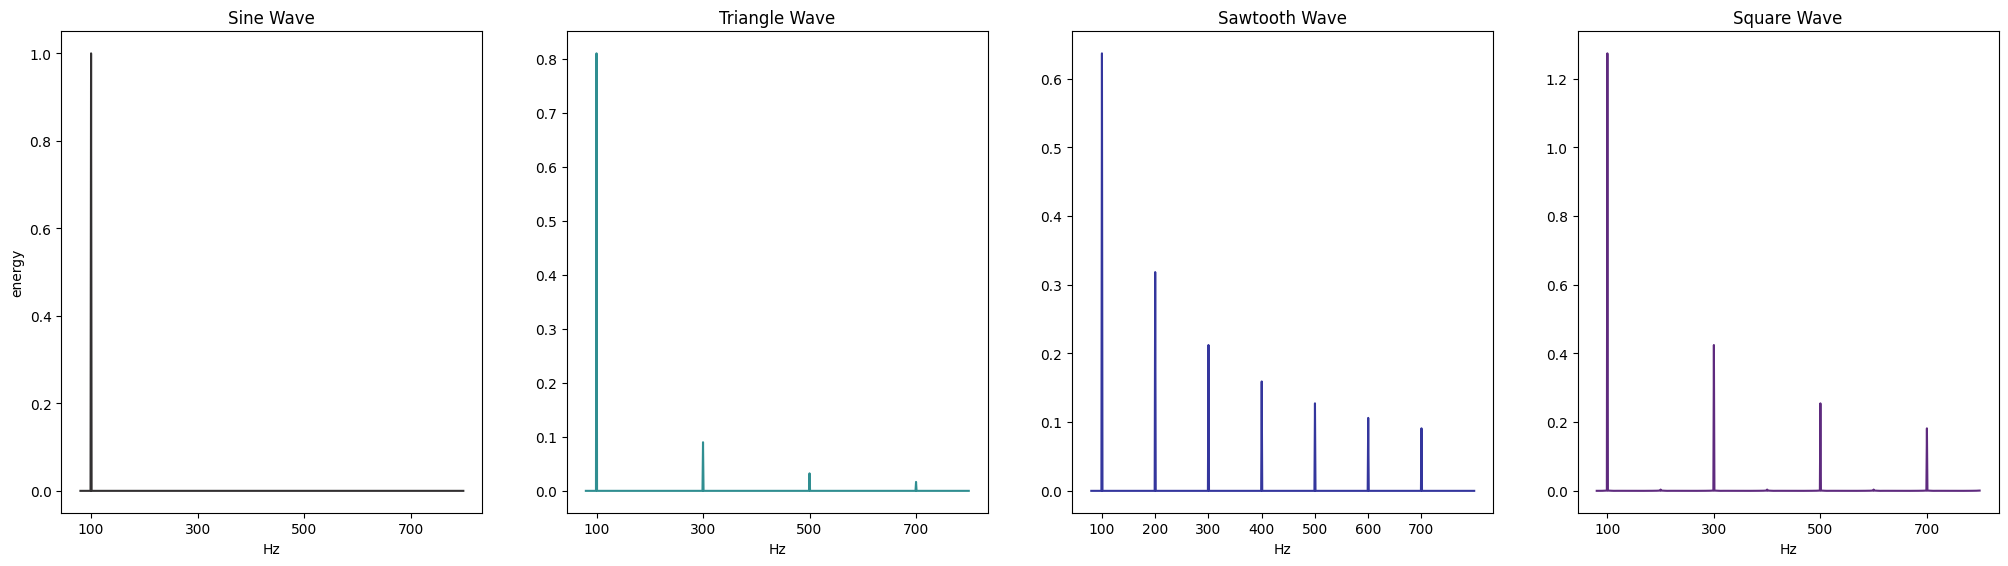

In [7]:
from engine.oscillators import TriangleOscillator, SawtoothOscillator, SquareOscillator

freq = 100; fslice = slice(80,800)
fig = plt.figure(figsize=figsize)

osc = SineOscillator(freq=freq)
x,y = fplot_xy(osc.get_samples(), fslice)
plot((x,y), 1,4,1,"Sine Wave", "Hz", "energy", color=colors[0], xticks=[100,300,500,700])

osc = TriangleOscillator(freq=freq)
x,y = fplot_xy(osc.get_samples(), fslice)
plot((x,y), 1,4,2, "Triangle Wave", "Hz", color=colors[1], xticks=[100,300,500,700])

osc = SawtoothOscillator(freq=freq)
x,y = fplot_xy(osc.get_samples(), fslice)
plot((x,y), 1,4,3, "Sawtooth Wave", "Hz", color=colors[2], xticks=[100,200,300,400,500,600,700])

osc = SquareOscillator(freq=freq)
x,y = fplot_xy(osc.get_samples(), fslice)
plot((x,y), 1,4,4, "Square Wave", "Hz", color=colors[3], xticks=[100,300,500,700])
